 # Visualization 1 — Regression Line (Model Behavior)

## Why are we plotting this?

Elastic Net is a **regression algorithm**, so it **does not have a decision boundary** like Logistic Regression or SVM.

Instead, we visualize the **regression line** learned by the model.

This graph helps us answer:

* Is the model fitting the data well?
* Is the line too steep?
* Is it too flat?
* Is the model underfitting?
* Is regularization affecting the fitted line?

This visualization is only practical when there is **one input feature**.

---

---

# What does the graph show?

You will see something similar to this:

```text
y

35 |                               •
32 |                          •
29 |                     •
26 |                •
23 |           •
20 |      •
17 |   •
14 | •
11 |
 8 |_________________________________________ x

          ● = Actual Data

          ───────────
          Red Line = Elastic Net Prediction
```

* **Blue dots** → Actual data points.
* **Red line** → Predictions made by the Elastic Net model.

The red line represents the equation:

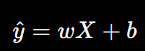

where (w) and (b) are the coefficients learned after applying Elastic Net regularization.

---

# How to Interpret It

## Case 1: Good Fit ✅

```
•     •
  •
    •
------ Red Line ------
       •
          •
```

The line passes through the center of the data.

This indicates:

* Good prediction.
* Neither overfitting nor underfitting.
* Appropriate amount of regularization.

---

## Case 2: Underfitting

```
•
          •

--------------------

          •
                    •
```

The line is almost flat.

Reasons:

* `alpha` is too large.
* Coefficients are shrunk too much.
* Model cannot capture the trend.

---

## Case 3: Slightly Different from Linear Regression

Suppose Linear Regression gives:

```
Slope = 3.20
```

Elastic Net may learn

```
Slope = 2.95
```

The line is slightly flatter because regularization penalizes large coefficients.

This is intentional and often improves performance on unseen data.

---

# What Can You Learn from This Graph?

This graph helps you answer:

* Is the learned relationship approximately linear?
* Is the model capturing the overall trend?
* Has regularization made the model too simple?
* Would changing `alpha` improve the fit?

---

# When Is This Visualization Useful?

✅ Learning how Elastic Net works.

✅ Comparing:

* Linear Regression
* Ridge
* Lasso
* Elastic Net

on the same one-dimensional dataset.

✅ Understanding the effect of regularization on the fitted line.

---

# Limitations

* Works well only with **one feature**.
* With two features, you would need a **3D regression plane**.
* With more than two features, this visualization is no longer practical.
---

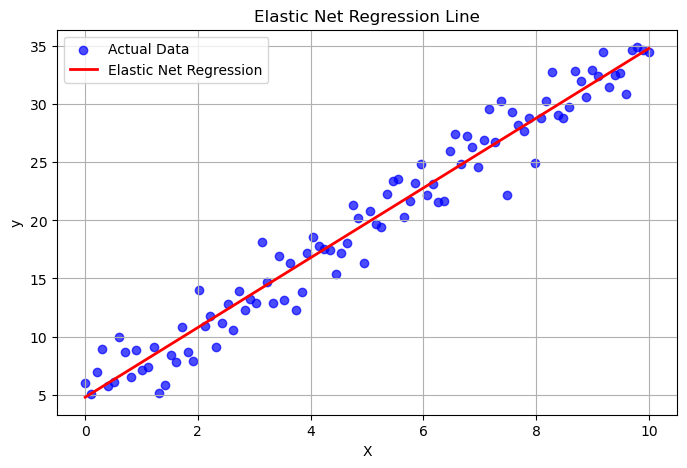

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

# Generate data
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)

y = (
        3 * X.ravel()
        + 5
        + np.random.normal(0, 2, 100)
)

# Train model
model = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5
)

model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    color="blue",
    alpha=0.7,
    label="Actual Data"
)

plt.plot(
    X,
    y_pred,
    color="red",
    linewidth=2,
    label="Elastic Net Regression"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Elastic Net Regression Line")

plt.legend()
plt.grid(True)

plt.show()

# Visualization 2 — Effect of `alpha` (Regularization Strength)

This is **the most important visualization** for Elastic Net.

If you understand this graph, you'll understand **how regularization changes the model**.

---

# Why are we plotting this?

The `alpha` parameter controls the **overall strength of regularization**.

As `alpha` changes:

* Coefficients change.
* The regression line changes.
* The model can move from **overfitting** to **underfitting**.

This graph helps answer:

* What happens when `alpha` is too small?
* What happens when `alpha` is too large?
* How does the regression line change?

---

# Code

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

# Dataset
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)

y = (
    3 * X.ravel()
    + 5
    + np.random.normal(0, 2, 100)
)

alphas = [0.001, 0.1, 10]

plt.figure(figsize=(8,6))

plt.scatter(
    X,
    y,
    color="black",
    alpha=0.6,
    label="Actual Data"
)

for alpha in alphas:

    model = ElasticNet(
        alpha=alpha,
        l1_ratio=0.5
    )

    model.fit(X, y)

    plt.plot(
        X,
        model.predict(X),
        linewidth=2,
        label=f"alpha={alpha}"
    )

plt.xlabel("X")
plt.ylabel("y")
plt.title("Effect of alpha on Elastic Net")

plt.legend()
plt.grid(True)

plt.show()
```

---

# What does the graph show?

You'll see **three regression lines**.

```text
y

35 |                           •
32 |                      •
29 |                 •
26 |            •
23 |        •
20 |    •
17 |  •
14 |
11 |_______________________________ x

     ───────── alpha = 0.001

      ─────── alpha = 0.1

         ──── alpha = 10
```

The exact positions will vary, but the pattern is always similar.

---

# Interpretation

## Line 1 — `alpha = 0.001`

```text
──────────────
```

Very weak regularization.

Almost identical to **Linear Regression**.

Characteristics:

* Large coefficients.
* Fits the data closely.
* Can overfit noisy datasets.

---

## Line 2 — `alpha = 0.1`

```text
──────────
```

Moderate regularization.

Characteristics:

* Coefficients become slightly smaller.
* Better generalization.
* Often gives the best test performance.

This is usually the desired region.

---

## Line 3 — `alpha = 10`

```text
──────
```

Strong regularization.

Characteristics:

* Coefficients shrink heavily.
* Line becomes flatter.
* Model ignores part of the trend.

May underfit.

---

# Why does the line become flatter?

Suppose Linear Regression learns

[
y = 3x + 5
]

Now increase `alpha`.

Elastic Net penalizes large coefficients.

The slope may become

```text
3.0
↓

2.5
↓

1.8
↓

1.0
↓

0.2
```

The prediction equation gradually becomes

```text
y = 3x + 5

↓

y = 2.5x + 5

↓

y = 1.8x + 5

↓

y = 0.2x + 5
```

As the slope gets smaller, the line becomes flatter.

---

# Effect on Coefficients

Suppose the true coefficients are

| Feature | Before |
| ------- | -----: |
| Area    |    8.5 |
| Rooms   |    4.2 |
| Garage  |    2.3 |

---

### Small alpha

| Feature | Coefficient |
| ------- | ----------: |
| Area    |         8.4 |
| Rooms   |         4.1 |
| Garage  |         2.2 |

Almost unchanged.

---

### Medium alpha

| Feature | Coefficient |
| ------- | ----------: |
| Area    |         6.5 |
| Rooms   |         3.1 |
| Garage  |         1.5 |

Notice all coefficients shrink.

---

### Large alpha

| Feature | Coefficient |
| ------- | ----------: |
| Area    |         2.0 |
| Rooms   |         0.8 |
| Garage  |           0 |

Now:

* L2 has shrunk the coefficients.
* L1 has removed one feature completely.

---

# Bias–Variance Perspective

| Alpha      | Bias     | Variance | Model               |
| ---------- | -------- | -------- | ------------------- |
| Very Small | Low      | High     | Can overfit         |
| Medium     | Balanced | Balanced | Best generalization |
| Very Large | High     | Low      | Can underfit        |

---

# When should you increase `alpha`?

Increase it when:

* The model is overfitting.
* Training score is much higher than test score.
* Coefficients are extremely large.
* The model is too complex.

---

# When should you decrease `alpha`?

Decrease it when:

* The model underfits.
* Both training and test scores are low.
* The regression line is almost flat.
* Predictions are nearly constant.

---

# Common Interview Question

### **Why does increasing `alpha` make the regression line flatter?**

**Answer:**

Increasing `alpha` increases the regularization penalty. This penalizes large coefficient values, causing the slope (and other coefficients) to shrink toward zero. As the slope decreases, the regression line becomes flatter. If `alpha` is too large, the model underfits because it becomes too simple to capture the relationship in the data.

---

# Key Takeaways

* `alpha` controls the **overall regularization strength**.
* Small `alpha` → behaves like Linear Regression.
* Medium `alpha` → usually best generalization.
* Large `alpha` → coefficients shrink significantly.
* Very large `alpha` → underfitting.
* This visualization helps understand the **bias–variance trade-off** introduced by regularization.

---

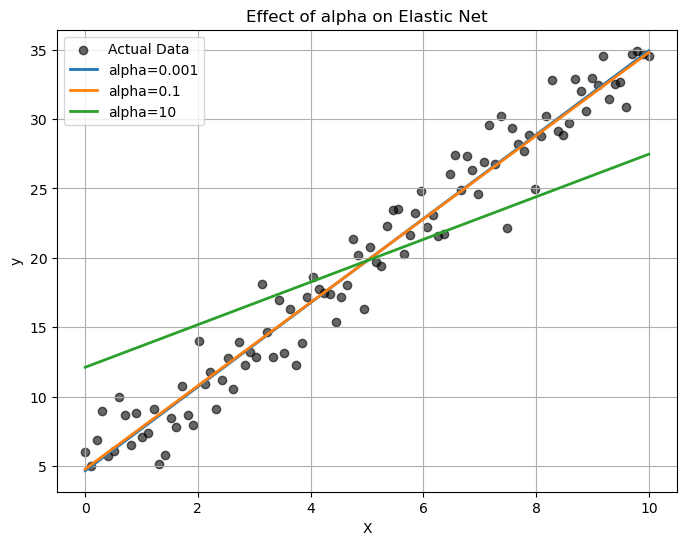

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

# Dataset
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)

y = (
        3 * X.ravel()
        + 5
        + np.random.normal(0, 2, 100)
)

alphas = [0.001, 0.1, 10]

plt.figure(figsize=(8,6))

plt.scatter(
    X,
    y,
    color="black",
    alpha=0.6,
    label="Actual Data"
)

for alpha in alphas:

    model = ElasticNet(
        alpha=alpha,
        l1_ratio=0.5
    )

    model.fit(X, y)

    plt.plot(
        X,
        model.predict(X),
        linewidth=2,
        label=f"alpha={alpha}"
    )

plt.xlabel("X")
plt.ylabel("y")
plt.title("Effect of alpha on Elastic Net")

plt.legend()
plt.grid(True)

plt.show()

# Visualization 3 — Effect of `l1_ratio` (Ridge ↔ Elastic Net ↔ Lasso)

This is the **second most important visualization** for Elastic Net.

Unlike `alpha`, which controls **how much regularization** is applied, `l1_ratio` controls **what type of regularization** is applied.

---

# Why are we plotting this?

`l1_ratio` determines the balance between:

* **L2 Regularization (Ridge)** → Shrinks coefficients.
* **L1 Regularization (Lasso)** → Removes coefficients.

This visualization answers:

* What changes when `l1_ratio` increases?
* When does Elastic Net behave like Ridge?
* When does it behave like Lasso?

---

# ❌ First Important Observation

Many tutorials plot the regression line for different `l1_ratio` values using **one feature**.

Example:

```python
l1_ratio = [0, 0.25, 0.5, 0.75, 1]
```

and plot five regression lines.

**This is NOT a very useful visualization.**

### Why?

Suppose there is only one feature.

```
House Area
```

Elastic Net has only **one coefficient**.

Whether you use

```
l1_ratio = 0
```

or

```
l1_ratio = 1
```

the regression line changes only slightly.

You learn almost nothing.

---

# The Better Visualization

The real strength of Elastic Net appears when there are **many features**.

Instead of plotting regression lines,

we plot the **coefficients** for different `l1_ratio` values.

This clearly shows:

* Which coefficients shrink.
* Which coefficients become zero.
* How Ridge gradually turns into Lasso.

---
---

# What does the graph show?

Imagine something like this:

```
Coefficient

 2.5 ┤ █
 2.0 ┤ █
 1.5 ┤ █
 1.0 ┤ █
 0.5 ┤ █
 0.0 ┼──────────────────────────
-0.5 ┤
-1.0 ┤
      Income Rooms Age ...

      █ = l1_ratio=0
      █ = l1_ratio=0.25
      █ = l1_ratio=0.5
      █ = l1_ratio=0.75
      █ = l1_ratio=1
```

Each feature has **five bars**.

Each bar corresponds to one value of `l1_ratio`.

---

# How to Interpret It

Let's look at one feature.

Suppose the graph shows

| l1_ratio | Coefficient |
| -------- | ----------: |
| 0        |        2.30 |
| 0.25     |        2.10 |
| 0.5      |        1.90 |
| 0.75     |        1.20 |
| 1        |           0 |

---

### What happened?

As `l1_ratio` increases,

the L1 penalty becomes stronger.

Eventually,

the coefficient becomes

```
0
```

The feature is removed.

---

# Another Feature

Suppose

| l1_ratio | Coefficient |
| -------- | ----------: |
| 0        |         1.8 |
| 0.25     |         1.7 |
| 0.5      |         1.7 |
| 0.75     |         1.6 |
| 1        |         1.5 |

Notice

It never becomes zero.

This means

This feature is extremely important.

Elastic Net keeps it regardless of the regularization type.

---

# Ridge vs Elastic Net vs Lasso

Imagine three correlated features.

```
Area

Rooms

Living Area
```

---

## Ridge (`l1_ratio = 0`)

```
Area          1.8

Rooms         1.6

Living Area   1.5
```

All features remain.

---

## Elastic Net (`l1_ratio = 0.5`)

```
Area          1.5

Rooms         1.2

Living Area   0.8
```

Still keeps all three,

but shrinks them.

---

## Lasso (`l1_ratio = 1`)

```
Area          2.4

Rooms         0

Living Area   0
```

Only one feature survives.

---

# Why is this graph important?

This graph demonstrates the **grouping effect**.

One of Elastic Net's biggest advantages is that it tends to keep groups of correlated features together, whereas Lasso may discard most of them.

---

# Common Pattern

```
l1_ratio

0

↓

0.25

↓

0.5

↓

0.75

↓

1
```

As you move downward:

* More L1 penalty.
* More coefficients become zero.
* Stronger feature selection.

---

# When should you increase `l1_ratio`?

Increase it when:

* You have many irrelevant features.
* You want a simpler model.
* Feature selection is important.

---

# When should you decrease `l1_ratio`?

Decrease it when:

* Many features are correlated.
* You don't want useful correlated features removed.
* You want more stable coefficients.

---

# Common Interview Question

### **Why is Elastic Net preferred over Lasso when features are highly correlated?**

**Answer:**

Lasso tends to select one feature from a group of highly correlated features and set the others to zero. Elastic Net combines L1 and L2 regularization, so it often keeps correlated features together while still shrinking their coefficients. This produces a more stable and interpretable model.

---

# Key Takeaways

* **Do not use a one-feature regression-line plot** to study `l1_ratio`; it hides the real behavior.
* The best visualization is a **coefficient comparison plot**.
* As `l1_ratio` increases:

  * The model behaves more like Lasso.
  * More coefficients become zero.
* As `l1_ratio` decreases:

  * The model behaves more like Ridge.
  * More correlated features are retained.
* This visualization explains the core advantage of Elastic Net: **balancing coefficient shrinkage and feature selection**.

---

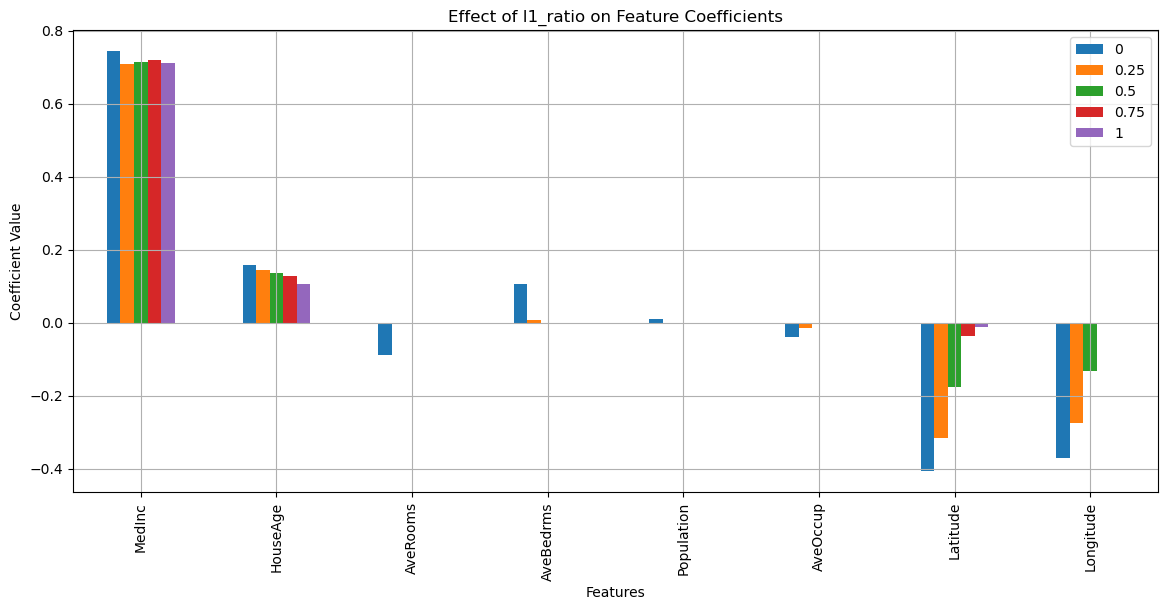

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

# Dataset
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

ratios = [0, 0.25, 0.5, 0.75, 1]

coef_df = pd.DataFrame(index=housing.feature_names)

for ratio in ratios:

    model = ElasticNet(
        alpha=0.1,
        l1_ratio=ratio,
        max_iter=10000
    )

    model.fit(X_train, y_train)

    coef_df[f"{ratio}"] = model.coef_

coef_df.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Effect of l1_ratio on Feature Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.grid(True)

plt.show()

# Visualization 4 — Learning Curve

This is one of the **most useful graphs** for any ML algorithm.

It helps answer:

* Is my model **overfitting**?
* Is it **underfitting**?
* Do I need **more data**?
* Is my model **generalizing well**?

---

# Why are we plotting this?

When you train a model, you usually see only one number:

```text
R² = 0.85
```

But this doesn't tell you **why** the score is good or bad.

A learning curve shows how the model performs as the amount of training data increases.

---

# What is plotted?

Two curves:

1. **Training Score**
2. **Validation (Cross-Validation) Score**

X-axis:

```text
Number of Training Samples
```

Y-axis:

```text
Performance (R²)
```

---
---

# How does `LearningCurveDisplay` work?

Let's break down this line:

```python
LearningCurveDisplay.from_estimator(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)
```

---

## `pipeline`

The model to evaluate.

```python
pipeline
```

contains

```text
StandardScaler
        ↓
ElasticNet
```

---

## `X`

Features.

---

## `y`

Target values.

---

## `cv=5`

For every training size,

perform **5-fold Cross Validation**.

Example:

```
10% data
↓

5-fold CV

↓

Average Training Score
Average Validation Score
```

Then

```
20% data

↓

Repeat
```

until

```
100% data
```

---

## `scoring="r2"`

The graph plots

```
R²
```

instead of accuracy.

---

## `train_sizes=np.linspace(0.1,1,10)`

This is very important.

```python
np.linspace(0.1,1,10)
```

returns

```python
array([
0.1,
0.2,
0.3,
0.4,
0.5,
0.6,
0.7,
0.8,
0.9,
1.0
])
```

Meaning

```
10%

20%

30%

...

100%
```

of the training data.

---

# What does the graph look like?

You'll usually see two curves.

```text
R²

1.0 |\
    | \
0.9 |  \
    |   \
0.8 |    \__________
    |
0.7 |       ________
    |      /
0.6 |_____/
    |
    +---------------------------->

      Training Samples
```

One curve:

```
Training Score
```

Second curve:

```
Validation Score
```

---

# How to Interpret It

There are **three common cases**.

---

# Case 1 — Good Model ✅

```text
R²

1.0 |

0.9 |\
    | \
0.8 |  \______

0.7 |      _____

0.6 |_____/_________________

       Training Samples
```

Notice:

* Training score decreases slightly.
* Validation score increases.
* Both meet.

### Interpretation

Excellent.

The model generalizes well.

Adding more data probably won't improve performance much.

---

# Case 2 — Overfitting

```text
R²

1.0 |────────────

0.9 |

0.8 |

0.7 |

0.6 |_______

0.5 |

     Training Samples
```

Training score

```
Very High
```

Validation score

```
Much Lower
```

Large gap.

---

### Why?

The model memorizes the training data.

It doesn't generalize.

---

### Solution

For Elastic Net

Increase

```python
alpha
```

because stronger regularization reduces overfitting.

---

# Case 3 — Underfitting

```text
R²

0.6 |────────

0.5 |────────

0.4 |

0.3 |

     Training Samples
```

Both curves are low.

Both overlap.

---

### Interpretation

The model is too simple.

Even the training data isn't fitted well.

---

### Solution

For Elastic Net

Decrease

```python
alpha
```

or engineer better features (e.g., polynomial features).

---

# What if the curves never meet?

Suppose

```text
Training

0.95

Validation

0.60
```

even after using all the data.

This usually means:

* The model is too complex.
* More regularization may help.
* Better feature engineering may be needed.

---

# What if both curves keep increasing?

Example:

```text
Training

0.72

↓

0.75

↓

0.78
```

Validation

```text
0.68

↓

0.71

↓

0.74
```

Both are still improving at the end.

### Interpretation

More training data may improve performance further.

---

# Why is this graph important?

Without a learning curve, if you see:

```text
R² = 0.65
```

you don't know whether:

* the model is overfitting,
* underfitting,
* or simply needs more data.

The learning curve tells you **why** the model is performing the way it is.

---

# Common Interview Question

### **What does a learning curve tell you?**

**Answer:**

A learning curve plots the training score and validation score as the amount of training data increases. It helps diagnose overfitting, underfitting, and whether collecting more data is likely to improve the model.

---

# Key Takeaways

* **X-axis:** Number of training samples.
* **Y-axis:** Model performance (typically R² for regression).
* Two curves are plotted:

  * Training score
  * Validation score
* **Large gap** → Overfitting.
* **Both low** → Underfitting.
* **Curves converge at a high score** → Good generalization.
* It's one of the best diagnostic tools for evaluating any supervised learning model.

---

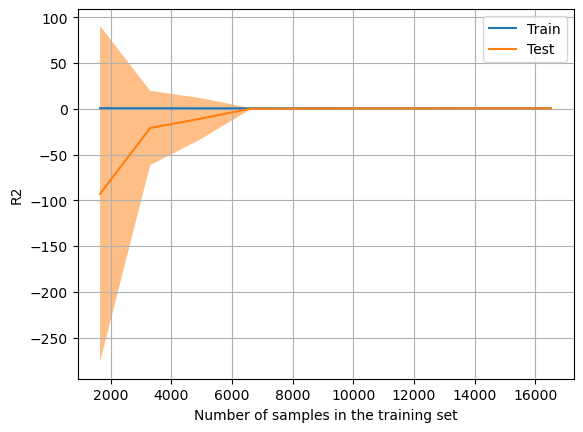

In [9]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import LearningCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Dataset
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        random_state=42,
        max_iter=10000
    ))
])

# Learning Curve
LearningCurveDisplay.from_estimator(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.grid(True)
plt.show()

## Important Graphs ot look at

`✅ Regression Line (to understand the model)
```✅ Effect of alpha
`````✅ Coefficient Plot (most important)
```````✅ Learning Curve
`````````✅ Residual Plot (I would actually add this—it is more useful in real projects than the l1_ratio line comparison)
```````````✅ Actual vs Predicted Scatter Plot (also widely used in practice)
``````#%% md
